## Research Proposal: Detecting Insider Threats through LLM-Based Embeddings and Anomaly Detection



# Project Introduction

## 1. Background

Insider threats are a critical security challenge. Because insiders act **within authorised boundaries**, their malicious behaviour blends into a large volume of legitimate activity, and genuine incidents are **exceedingly rare**. Email is a primary channel for such activity (data exfiltration, unauthorised disclosure), making it a natural focus for detection.

**Core idea:** represent each user's email behaviour through both **metadata** and the **semantic content** of their messages (via LLM embeddings), then detect deviations from normal patterns.

---

## 2. Research Objectives

1. **Convert raw emails to meaningful representations** — use pre-trained LLMs to generate embeddings capturing tone, topic, and deviation from a user's normal communication patterns, combined with behavioural metadata (volume, recipients, size, attachments, timing).
2. **Build an anomaly-detection framework** — flag emails or users deviating from established norms. The modelling approach is deliberately open-ended: start with simple, interpretable methods and progress to more advanced ML/DL techniques.
3. **Experiment with the CERT Insider Threat Dataset** — measure detection effectiveness under severe class imbalance, while respecting realistic analyst workload constraints.

---

## 3. Dataset: CERT Insider Threat Dataset (r6.2)

A synthetic dataset from the CERT Division (Software Engineering Institute), providing realistic background activity for **4,000 users** alongside injected malicious insider scenarios — avoiding the privacy and labelling problems of real data. An accompanying **answers file** lists the malicious scenarios and the user IDs involved, providing ground truth for evaluation.

### Files in scope

| File | Role in the project |
|---|---|
| email.csv | **Primary data source** for anomaly detection |
| LDAP files | Organisational structure and user-profile data for **context/enrichment** |

### Key properties

- **Content is written as complete sentences** — suitable for both LLM embeddings and classical text pre-processing (tokenisation, stop-word removal, stemming).
- **Email traffic follows an underlying organisational graph** — most sender–recipient pairs are genuine, with a few random edges as noise. Recipients may be internal (DTAA) or external (non-DTAA). Off-graph or external recipients, and unusual volume, size, or attachment counts, act as natural anomaly signals.
- **Malicious insiders are extremely rare** — this frames the task as rare-event anomaly detection.

### Downloading and extracting

Download the dataset from the **CERT Insider Threat Test Dataset page** (Carnegie Mellon University). Due to its size, it is easier to extract from the terminal than through a GUI:

```bash
tar -xvf ~/Downloads/r6.2.tar.bz2 -C ~/Downloads
```

---

## 4. Methodology

Three stages, each a recommended direction rather than a fixed procedure.

### Stage 1 — Feature Engineering
- Aggregate emails **per user over a temporal window**.
- Build two complementary representations: **metadata features** (volume, recipients, size, attachments, timing) and **semantic features** from pre-trained language model embeddings of message content.
- Features capturing **deviation from each user's historical baseline** are expected to be particularly informative. Dimensionality reduction may be applied for efficiency.

### Stage 2 — Modelling
- Start with **simple, interpretable baselines** to establish reference performance.
- Progress to **classical anomaly-detection and supervised methods** (e.g. clustering-based scoring, PCA reconstruction error), and consider **combining detectors** — ensembles of complementary methods can substantially improve detection.
- Move on to **embedding-driven or deep-learning approaches**, and compare trade-offs at each step.

### Stage 3 — Training and Evaluation
- Train detectors on **normal behaviour**, then score held-out data.
- Evaluate under operational conditions: report **detection rate at anomaly-score cut-offs** (e.g. top 1%, 5%, 10% of scores), reflecting a realistic analyst workload rather than raw accuracy.

---

## 5. Suggested Workflow

1. **Explore** `email.csv` and LDAP — profile users, roles, internal vs external traffic over time.
2. **Prepare ground truth** — parse the answers file; keep it strictly for evaluation.
3. **Pre-process content** — classical NLP pipeline and/or LLM embeddings of message content.
4. **Baseline** — metadata features + a simple detector; record detection rate at score cut-offs.
5. **Add semantics** — per-user embedding-based deviation features; compare against the baseline.
6. **Compare and combine models** — under identical temporal splits and evaluation budgets.
7. **Analyse and report** — which threats are caught or missed, and the trade-offs between interpretability, performance, and compute.

# Getting started with embeddings

**Project Objective 1: Convert Raw Emails to Meaningful Representations**

Feature engineering is a very important part of training a good anomaly detection model. In this project, we want to extract the features that most likely indicate a malicious email. Because email data is primarily text, it becomes important how we convert the text into formats that can be processed by models.

Some features can be derived from meta-data, e.g. recipient anomalies (whether the recipient is internal or external), volume and timing of email sent based on the user's baseline, size and attachments. While some features can be derived from content of the email using semantics, e.g. semantic deviation, content red flags (presence of sensitive words), role mismatch.

Word-embedding becomes very useful in the latter type of features, and this section is a hands-on introduction to *embeddings* — the technique we'll use to turn
the free-text content of emails into numbers that a model can reason about.

You don't need a deep learning background for this. Everything here builds on ideas you
already know from statistics: vectors, distance, correlation, and dimensionality reduction
(PCA). We'll start from something very simple and work our way up to the kind of
pretrained language model embeddings you'll use in the project.

**By the end of this section you should be able to:**
1. Explain what an embedding is and why "closeness" in the vector space is meaningful.
2. Build simple document vectors yourself (TF-IDF) and see their limitations.
3. Understand what a pretrained LLM embedding adds on top of that.
4. Turn an email's embedding into a per-user *deviation score* — a potential semantic feature you can use in your model.

In [1]:
# importing python packages that will be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

np.random.seed(42)
pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.figsize"] = (6, 4)


ModuleNotFoundError: No module named 'numpy'

## 1. What is an embedding?

An embedding is just a **rule for turning an object
(a word, a sentence, an email) into a point in $\mathbb{R}^d$** — a vector of $d$ numbers —
such that objects with *similar meaning* end up as points that are *close together*.

That's it. The interesting part is *how* you choose that rule so that "closeness in the
vector space" actually lines up with "closeness in meaning".

### Why not just use one-hot vectors?

The simplest possible encoding of a word is a one-hot vector: pick a vocabulary of size
$V$, and represent word $i$ as a vector of length $V$ that's all zeros except a 1 in
position $i$.

The problem: every pair of distinct words is **equally far apart**, no matter how related
they are. "money" and "invoice" are just as dissimilar as "money" and "kangaroo" — the
representation carries no information about meaning, only identity.

In [ ]:
vocab = ["money", "invoice", "payment", "kangaroo", "resign"]

one_hot = np.eye(len(vocab))
df_onehot = pd.DataFrame(one_hot, index=vocab, columns=vocab)
print("One-hot vectors:")
display(df_onehot)

sim = cosine_similarity(one_hot)
print("\nCosine similarity between every pair (should all be 0 off-diagonal):")
display(pd.DataFrame(sim, index=vocab, columns=vocab).round(2))

One-hot vectors:


,money,invoice,payment,kangaroo,resign
money,1.0,0.0,0.0,0.0,0.0
invoice,0.0,1.0,0.0,0.0,0.0
payment,0.0,0.0,1.0,0.0,0.0
kangaroo,0.0,0.0,0.0,1.0,0.0
resign,0.0,0.0,0.0,0.0,1.0



Cosine similarity between every pair (should all be 0 off-diagonal):


,money,invoice,payment,kangaroo,resign
money,1.0,0.0,0.0,0.0,0.0
invoice,0.0,1.0,0.0,0.0,0.0
payment,0.0,0.0,1.0,0.0,0.0
kangaroo,0.0,0.0,0.0,1.0,0.0
resign,0.0,0.0,0.0,0.0,1.0


## 2. First embedding: TF-IDF document vectors

Before jumping to LLMs, let's build a real, useful embedding ourselves using something
you've likely already seen in a stats course: a **term-document matrix**.

Each row is a document (an email), each column is a word in the vocabulary, and each
entry is a weighted count of how often that word appears — down-weighted if the word is
common across *all* documents (that's the "IDF", inverse document frequency, part). This
is exactly the kind of matrix you'd build for a contingency-table-style analysis.

The result: each email becomes a vector, and emails that use similar words point in
similar directions.

Let's build a small toy inbox — a handful of ordinary work emails and one that looks
out of place.

In [ ]:
toy_emails = pd.DataFrame({
    "email_id": range(1, 9),
    "user": ["alice"]*4 + ["alice"]*3 + ["alice"],
    "label": ["normal"]*7 + ["suspicious"],
    "text": [
        "Please find attached the quarterly budget report for review.",
        "Can we schedule a meeting to discuss the project timeline?",
        "Here is the invoice for last month's office supplies.",
        "Reminder: team standup is moved to 10am tomorrow.",
        "Attaching the updated slide deck for the client presentation.",
        "Let me know if you have questions about the payment schedule.",
        "The budget report has been updated with the latest figures.",
        "Please send the full client database and login credentials to my personal email before I leave the company.",
    ],
})
toy_emails

,email_id,user,label,text
0,1,alice,normal,Please find attached the quarterly budget report for rev...
1,2,alice,normal,Can we schedule a meeting to discuss the project timeline?
2,3,alice,normal,Here is the invoice for last month's office supplies.
3,4,alice,normal,Reminder: team standup is moved to 10am tomorrow.
4,5,alice,normal,Attaching the updated slide deck for the client presenta...
5,6,alice,normal,Let me know if you have questions about the payment sche...
6,7,alice,normal,The budget report has been updated with the latest figures.
7,8,alice,suspicious,Please send the full client database and login credentia...


In [ ]:
vectorizer = TfidfVectorizer(stop_words="english")  # use stop_words to remove common english words like "the, is, at, which, and, to..."
tfidf_matrix = vectorizer.fit_transform(toy_emails["text"])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  "
      f"(8 emails x {tfidf_matrix.shape[1]} vocabulary terms)")

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=toy_emails["email_id"],
    columns=vectorizer.get_feature_names_out()  # each column is a word in the vocabulary terms
)
# show a slice of columns so it's readable
tfidf_df.iloc[:, :10].round(2)

TF-IDF matrix shape: (8, 40)  (8 emails x 40 vocabulary terms)


,10am,attached,attaching,budget,client,company,credentials,database,deck,discuss
email_id,,,,,,,,,,
1,0.00,0.48,0.00,0.40,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.46
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.43,0.00,0.36,0.00,0.00,0.00,0.43,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,0.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00
8,0.00,0.00,0.00,0.00,0.28,0.34,0.34,0.34,0.00,0.00


### Now what? Comparing email vectors

Each row of `tfidf_df` is now a point in a high-dimensional space — one dimension per
vocabulary word. That's useful, but a table of numbers isn't very interpretable on its
own. What we actually care about is: **which emails are similar to which others?**

Geometrically, this comes down to a simple question: given two vectors, how "close"
are they? There are a couple of natural ways to define "close":

- **Euclidean distance** — the straight-line distance between two points, same as
  you'd compute in 2D or 3D. The problem for text: a long email and a short email on
  the *exact same topic* can end up far apart in Euclidean distance, just because the
  long one has bigger word counts overall — length distorts the comparison.
- **Cosine similarity** — instead of measuring the distance between two points, this
  measures the *angle* between the two vectors (drawn from the origin). Two vectors
  pointing in the same direction score close to 1, regardless of their length. Two
  unrelated vectors (roughly orthogonal, sharing no common words) score close to 0.

For text, cosine similarity is the standard choice precisely because it factors out
document length and focuses on *word usage pattern* — a short email and a long email
about the same topic will point in a similar direction even if their raw magnitudes
differ a lot. We'll use it in this notebook.

### Measuring closeness: cosine similarity

The standard way to compare two embedding vectors is **cosine similarity** — the cosine
of the angle between them:

$$\text{sim}(u, v) = \frac{u \cdot v}{\lVert u \rVert \, \lVert v \rVert}$$

It ranges from $-1$ (opposite) to $1$ (identical direction), and is popular for text
because it ignores vector *length* (i.e. document length) and focuses purely on
*direction* (i.e. word usage pattern).


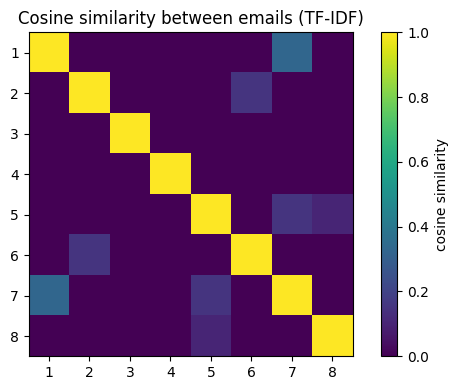


Email 8 is the odd one out - the suspicious request.
Its similarity to the other emails:
email_id
1    0.0
2    0.0
3    0.0
4    0.0
5    0.1
6    0.0
7    0.0
Name: 8, dtype: float64


In [ ]:
sim_matrix = cosine_similarity(tfidf_matrix)
sim_df = pd.DataFrame(sim_matrix, index=toy_emails["email_id"], columns=toy_emails["email_id"])

fig, ax = plt.subplots()
im = ax.imshow(sim_df, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(sim_df))); ax.set_xticklabels(sim_df.columns)
ax.set_yticks(range(len(sim_df))); ax.set_yticklabels(sim_df.index)
ax.set_title("Cosine similarity between emails (TF-IDF)")
plt.colorbar(im, label="cosine similarity")
plt.tight_layout()
plt.show()

print("\nEmail 8 is the odd one out - the suspicious request.")
print("Its similarity to the other emails:")
print(sim_df[8].drop(8).round(2))

### What does this actually show us?

Look at email 8's similarity scores above — they're close to zero across the board.
At first glance that might look like a clean anomaly signal. But check the similarity
*between the normal emails themselves* (emails 1–7): those are barely higher, often
close to zero too.

In other words, TF-IDF isn't confidently flagging email 8 as unusual — it's failing to
find much similarity between *any* of these emails, suspicious or not. That's a real
limitation of TF-IDF, not a quirk of this dataset: short documents with little exact
word overlap end up with sparse, mostly-disjoint vectors even when they're topically
related. "budget report" and "invoice" are both about money, but they don't share
enough literal vocabulary for TF-IDF to notice.

This is exactly the gap that pretrained LLM embeddings are built to close — they don't
need exact word overlap to recognise that two pieces of text are semantically related.
We'll see that difference directly once we compare the two approaches side by side.

### Visualising the embedding space (dimensionality reduction)

Our TF-IDF vectors live in a space with as many dimensions as there are vocabulary
words — too many to plot. Just like you'd use **PCA** to visualise a high-dimensional
dataset in stats, we can project these vectors down to 2 dimensions to see the structure.

In [ ]:
# function to make the labels not overlap with each other
def stagger_offsets(coords, tol=1e-6, base_offset=10, step=12):
    n = len(coords)
    group_id = -np.ones(n, dtype=int)
    groups = []
    for i in range(n):
        if group_id[i] != -1:
            continue
        members = [i]
        for j in range(i + 1, n):
            if group_id[j] == -1 and np.allclose(coords[i], coords[j], atol=tol):
                members.append(j)
        gid = len(groups)
        groups.append(members)
        for m in members:
            group_id[m] = gid

    offsets = [None] * n
    for members in groups:
        for rank, idx in enumerate(members):
            dx = base_offset / 2 if rank % 2 == 0 else -base_offset / 2 - 20
            dy = base_offset / 2 + rank * step
            offsets[idx] = (dx, dy)
    return offsets

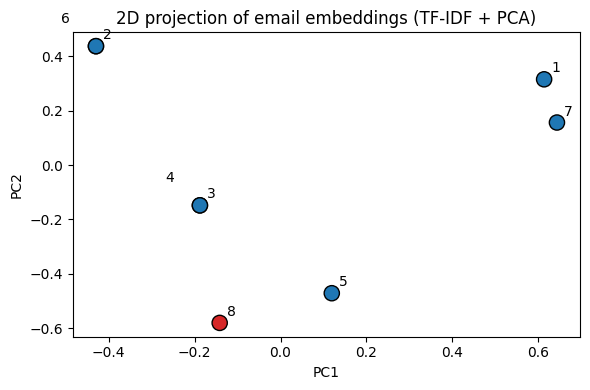

Variance explained by 2 components: 34.9%


In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
offsets = stagger_offsets(coords)

fig, ax = plt.subplots()
colors = toy_emails["label"].map({"normal": "tab:blue", "suspicious": "tab:red"})
ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=120, edgecolor="k")
for i, txt in enumerate(toy_emails["email_id"]):
    ax.annotate(txt, (coords[i, 0], coords[i, 1]), xytext=offsets[i], textcoords="offset points")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("2D projection of email embeddings (TF-IDF + PCA)")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

### Where TF-IDF falls short

TF-IDF is a **bag-of-words** method — it only cares about which words are used, not their
order or context, and it has no notion of meaning beyond exact word overlap.

This is exactly the gap that pretrained **LLM embeddings** are designed to close.

## 3. From word counts to LLM embeddings

A pretrained language model embedding is built the same way conceptually — text in,
vector out — but the *rule* for producing that vector is learned from an enormous amount
of text, rather than hand-crafted word counts. The model has effectively learned which
sentences tend to appear in similar contexts, so it can represent:

- **Synonymy** — different words, same meaning, end up close together.
- **Context** — the same word in different contexts ends up in different places.
- **Tone and topic** — sentences that "feel" similar (formal vs urgent, technical vs
  personal) cluster together, not just sentences that share vocabulary.

You don't need to know how the model itself works internally to use it — you can treat
it as a function: `text -> vector`, exactly like `TfidfVectorizer.transform` above, just a
much more powerful one. To begin, we'll install the `sentence-transformers` library, which provides an easy way to use state-of-the-art embedding models. Then, we'll load a pre-trained model and generate embeddings for a sample text.

In [5]:
# install the sentence-transformers library
!pip install -U sentence-transformers

In [6]:
from sentence_transformers import SentenceTransformer

# load a pre-trained embedding model (e.g., 'all-MiniLM-L6-v2') this model is good for general-purpose sentence embeddings and is relatively lightweight.
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Embedding model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully.


In [8]:
text_to_embed = [
    'This is an example sentence.',
    'Each sentence is converted into a vector.',
    'Research Proposal: Detecting Insider Threats through Embeddings and Contextual Multi-armed Bandit models'
]

# generate embeddings for the text
embeddings = model.encode(text_to_embed)

# print the embeddings and their shape
print("Generated Embeddings:")
for i, embedding in enumerate(embeddings):
    print(f"Embedding for '{text_to_embed[i]}'\n  Shape: {embedding.shape}\n  First 5 dimensions: {embedding[:5].tolist()}\n")

print(f"Overall embeddings shape: {embeddings.shape}")

Generated Embeddings:
Embedding for 'This is an example sentence.'
  Shape: (384,)
  First 5 dimensions: [0.09812464565038681, 0.06781267374753952, 0.06252317875623703, 0.09508482366800308, 0.03664755821228027]

Embedding for 'Each sentence is converted into a vector.'
  Shape: (384,)
  First 5 dimensions: [0.05166657269001007, 0.04801540449261665, -0.02464962750673294, -0.002247906057164073, 0.024548163637518883]

Embedding for 'Research Proposal: Detecting Insider Threats through Embeddings and Contextual Multi-armed Bandit models'
  Shape: (384,)
  First 5 dimensions: [-0.07895272970199585, -0.04394177347421646, -0.015742624178528786, -0.024837706238031387, 0.0995887815952301]

Overall embeddings shape: (3, 384)


As you can see, each sentence has been converted into a fixed-size numerical vector (in this case, 384 dimensions). These vectors capture the semantic meaning of the sentences and can be used for tasks like similarity search, clustering, or as input features for other machine learning models.

Now, we convert the same toy_emails dataset from above into word embeddings and plot the cosine similarity.

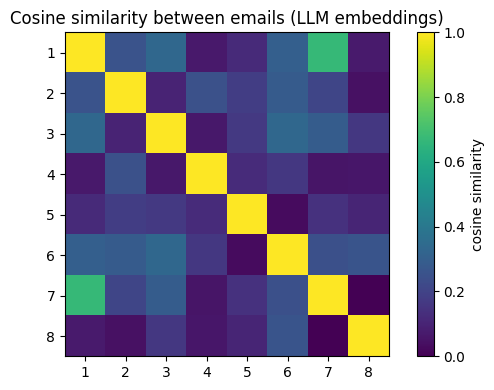


Email 8's similarity to the other emails (LLM embeddings):
email_id
1    0.07
2    0.04
3    0.16
4    0.06
5    0.10
6    0.26
7   -0.06
Name: 8, dtype: float32


In [ ]:
# generate embeddings for every email in the toy dataset
llm_embeddings = model.encode(toy_emails["text"].tolist())

sim_matrix_llm = cosine_similarity(llm_embeddings)
sim_df_llm = pd.DataFrame(sim_matrix_llm, index=toy_emails["email_id"], columns=toy_emails["email_id"])

fig, ax = plt.subplots()
im = ax.imshow(sim_df_llm, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(sim_df_llm))); ax.set_xticklabels(sim_df_llm.columns)
ax.set_yticks(range(len(sim_df_llm))); ax.set_yticklabels(sim_df_llm.index)
ax.set_title("Cosine similarity between emails (LLM embeddings)")
plt.colorbar(im, label="cosine similarity")
plt.tight_layout()
plt.show()

print("\nEmail 8's similarity to the other emails (LLM embeddings):")
print(sim_df_llm[8].drop(8).round(2))

In [ ]:
# mean similarity of email 8 to the other 7 emails
tfidf_8_vs_others = sim_df[8].drop(8).mean()
llm_8_vs_others = sim_df_llm[8].drop(8).mean()

# mean similarity among the 7 normal emails themselves (excludes diagonal, each pair once)
tfidf_others_vs_others = sim_df.loc[1:7, 1:7].values[np.triu_indices(7, 1)].mean()
llm_others_vs_others = sim_df_llm.loc[1:7, 1:7].values[np.triu_indices(7, 1)].mean()

print("TF-IDF:")
print(f"  email 8 vs others:  {tfidf_8_vs_others:.3f}")
print(f"  others vs others:   {tfidf_others_vs_others:.3f}")
print(f"  gap:                {tfidf_8_vs_others - tfidf_others_vs_others:+.3f}")

print("\nLLM embeddings:")
print(f"  email 8 vs others:  {llm_8_vs_others:.3f}")
print(f"  others vs others:   {llm_others_vs_others:.3f}")
print(f"  gap:                {llm_8_vs_others - llm_others_vs_others:+.3f}")

TF-IDF:
  email 8 vs others:  0.015
  others vs others:   0.030
  gap:                -0.015

LLM embeddings:
  email 8 vs others:  0.093
  others vs others:   0.209
  gap:                -0.116


### TF-IDF vs LLM embeddings: does semantic similarity help?

Under **TF-IDF**, email 8 looked no more distinct than the normal emails were from
each other — mean similarity to the rest was ≈0, but so was similarity *among* the
normal emails (≈0.03). TF-IDF wasn't really separating it, it was just failing to find
overlap between any short email.

Under **LLM embeddings**, email 8's similarity to the others is 0.093, versus
0.209 among the normal emails — a larger gap than TF-IDF showed.

This is expected: LLM embeddings capture *meaning*, not just shared words, so related
emails ("budget report", "invoice") end up closer together even without overlapping
vocabulary — something TF-IDF can't do.

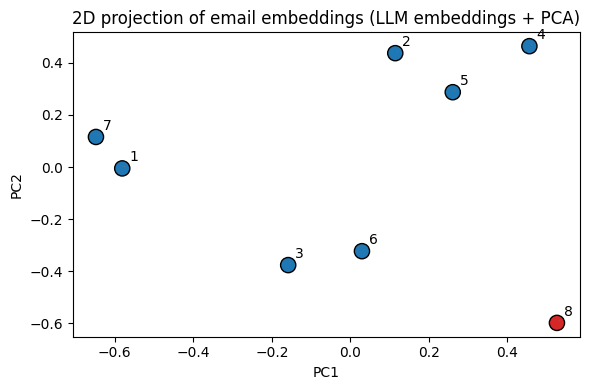

Variance explained by 2 components: 42.8%


In [ ]:
# PCA plot of word embeddgings
pca_llm = PCA(n_components=2, random_state=42)
coords_llm = pca_llm.fit_transform(llm_embeddings)

fig, ax = plt.subplots()
colors = toy_emails["label"].map({"normal": "tab:blue", "suspicious": "tab:red"})
ax.scatter(coords_llm[:, 0], coords_llm[:, 1], c=colors, s=120, edgecolor="k")

offsets = stagger_offsets(coords_llm)
for i, txt in enumerate(toy_emails["email_id"]):
    ax.annotate(
        txt,
        (coords_llm[i, 0], coords_llm[i, 1]),
        xytext=offsets[i],
        textcoords="offset points",
        arrowprops=dict(arrowstyle="-", lw=0.5, color="gray"),
    )

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("2D projection of email embeddings (LLM embeddings + PCA)")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca_llm.explained_variance_ratio_.sum():.1%}")

## 4. From embeddings to a deviation score

This is where word representation turns into a detection signal in the model.
The proposal specifically highlights this idea:

> "Features capturing deviation from each user's historical baseline are expected to be
> particularly informative."

The recipe is simple once each email is a vector:

1. For each user, compute a **baseline vector** — e.g. the average embedding of that
   user's historical (assumed-normal) emails.
2. For each new email, compute its **distance** from that user's baseline (cosine
   distance = $1 - \text{cosine similarity}$ works well here).
3. Emails whose distance is unusually large relative to that user's normal spread are
   flagged as anomalous.

In [ ]:
def user_baseline(embeddings, normal_mask):
    '''Mean embedding vector across a user's normal (baseline) emails.'''
    return embeddings[normal_mask].mean(axis=0)

def deviation_scores(embeddings, baseline):
    '''Cosine distance of every email's embedding from the baseline vector.'''
    return cosine_distances(embeddings, baseline.reshape(1, -1)).ravel()

# Treat the first 7 (labelled 'normal') emails as Alice's historical baseline
normal_mask = (toy_emails["label"] == "normal").values
baseline_vec = user_baseline(llm_embeddings, normal_mask)

toy_emails["deviation_score"] = deviation_scores(llm_embeddings, baseline_vec)
toy_emails[["email_id", "label", "deviation_score"]].sort_values("deviation_score", ascending=False)

,email_id,label,deviation_score
7,8,suspicious,0.836956
3,4,normal,0.566026
4,5,normal,0.555915
1,2,normal,0.426080
2,3,normal,0.423658
5,6,normal,0.406376
6,7,normal,0.342337
0,1,normal,0.307485


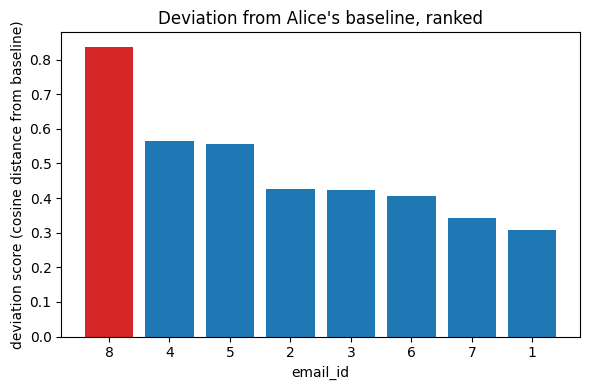

In [ ]:
fig, ax = plt.subplots()
bar_colors = toy_emails.sort_values("deviation_score", ascending=False)["label"].map(
    {"normal": "tab:blue", "suspicious": "tab:red"})
ordered = toy_emails.sort_values("deviation_score", ascending=False)
ax.bar(ordered["email_id"].astype(str), ordered["deviation_score"], color=bar_colors)
ax.set_xlabel("email_id"); ax.set_ylabel("deviation score (cosine distance from baseline)")
ax.set_title("Deviation from Alice's baseline, ranked")
plt.tight_layout()
plt.show()


# Loading and Exploratory Analysis of CERT Email Data

In this section, we begin working with the actual **CERT Insider Threat Dataset**. Because the `email.csv` file is roughly 8GB, loading it entirely into memory could lead to a system crash.

Instead, we implement a **memory-efficient inspection strategy** using pandas' chunking and row-limiting features. This allows us to:
1.  **Validate the schema:** Confirming the 12 fields (id, user, activity, etc.) match the readme.txt.
2.  **Audit data distributions:** Checking email sizes and activity types without overloading RAM.
3.  **Prepare for feature engineering:** Understanding the data types before we apply any feature engineering techniques.

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import pandas as pd

# Path to the file in your specific folder
file_path = '/content/drive/MyDrive/UoE26/email.csv'

# Since the file is 7.5GB, we load a small chunk first to see the structure
try:
    # Reading just the first 10,000 rows to avoid memory issues
    df_preview = pd.read_csv(file_path, nrows=10000)

    print("--- Data Preview (First 5 rows) ---")
    display(df_preview.head())

    print("\n--- Column Info ---")
    display(df_preview.info())

    print("\n--- Unique Values (Sample) ---")
    print(f"Unique Users in sample: {df_preview['user'].nunique()}")
    print(f"Activity Types: {df_preview['activity'].unique()}")

except FileNotFoundError:
    print(f"Error: Could not find 'email.csv' at {file_path}. Please verify the path.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Data Preview (First 5 rows) ---


,id,date,user,pc,to,cc,bcc,from,activity,size,attachments,content
0,{I1O2-B4EB49RW-7379WSQW},01/02/2010 06:36:41,HDB1666,PC-6793,Louis.Bernard.Garza@dtaa.com,Emery.Ali.Holloway@dtaa.com,Hector.Donovan.Bray@dtaa.com,Hector.Donovan.Bray@dtaa.com,Send,45659,NaN,"Now Sylvia, the object of Aminta's desire, arr..."
1,{L7E7-V4UX89RR-3036ZDHU},01/02/2010 06:40:02,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,NaN,NaN,Luke.Grant.Mcmahon@dtaa.com,View,34142,NaN,"On May 14, they picked up 44 more Iroquois at ..."
2,{S8C2-Q8YX87DJ-0516SIWZ},01/02/2010 06:42:48,HDB1666,PC-6793,Quintessa.O.Farrell@harris.com,Hector.Donovan.Bray@dtaa.com,NaN,Hector.Donovan.Bray@dtaa.com,Send,1310925,C:\28X79b6\0PAGXTJ8.doc(1119253);C:\11b38g6\5M...,Sylvia is notable for its mythological Arcadia...
3,{A1V9-O5BL46SW-1708NAEC},01/02/2010 06:45:42,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,NaN,NaN,Travis.Ezra.Warner@dtaa.com,View,23043,NaN,Lanctot (1967) and Smith do not identify any s...
4,{N6R0-M2EI82DM-5583LSUM},01/02/2010 06:47:07,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,NaN,NaN,Kenyon.William.Delacruz@dtaa.com,View,25210,NaN,Much like all the other large groups of prison...



--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           10000 non-null  object
 1   date         10000 non-null  object
 2   user         10000 non-null  object
 3   pc           10000 non-null  object
 4   to           10000 non-null  object
 5   cc           2836 non-null   object
 6   bcc          1014 non-null   object
 7   from         10000 non-null  object
 8   activity     10000 non-null  object
 9   size         10000 non-null  int64 
 10  attachments  1169 non-null   object
 11  content      10000 non-null  object
dtypes: int64(1), object(11)
memory usage: 937.6+ KB


None


--- Unique Values (Sample) ---
Unique Users in sample: 1878
Activity Types: ['Send' 'View']


In [6]:
# Calculate basic distribution of email sizes and attachments using a larger chunk
try:
    chunk_iter = pd.read_csv(file_path, chunksize=100000, usecols=['size', 'attachments', 'activity'])
    first_chunk = next(chunk_iter)

    print("--- Summary Statistics for first 100k rows ---")
    display(first_chunk.describe())

    print("\n--- Activity Distribution ---")
    display(first_chunk['activity'].value_counts())
except Exception as e:
    print(f"Could not calculate statistics: {e}")

--- Summary Statistics for first 100k rows ---


,size
count,1.000000e+05
mean,3.440215e+05
std,9.050375e+05
min,7.376000e+03
25%,2.417300e+04
50%,3.132800e+04
75%,4.488500e+04
max,1.229464e+07



--- Activity Distribution ---


,count
activity,
View,63596
Send,36404


# Semantic Analysis of a Single User's Email Activity

To move from the toy example to the real CERT dataset, we will apply the following strategy:

1.  **Identify a Target User:** We'll look for a user with enough email activity to form a meaningful baseline.
2.  **Filter Content:** We'll extract the `content` of their emails. Note that in the CERT dataset, 'content' is a space-separated list of keywords representing topics.
3.  **Generate Embeddings:** We will use the `SentenceTransformer` model to convert these keyword-based contents into 384-dimensional vectors.
4.  **Clustering & Visualization:** We'll use PCA to see if the user's emails naturally group into semantic clusters (e.g., related to specific projects or topics).

Targeting User: BOR2387 with 74 emails.
Generating embeddings (this may take a moment)...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

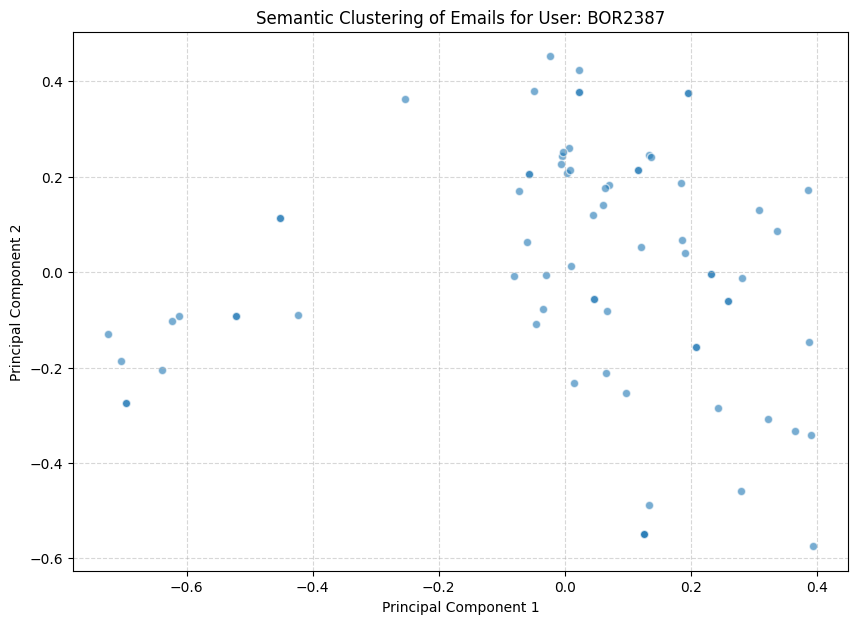

Shape of generated embeddings: (74, 384)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# pick a user with significant activity from the initial chunk
# We'll reload a larger chunk to ensure we find a good candidate
try:
    chunk = pd.read_csv(file_path, nrows=50000, usecols=['user', 'content'])
    user_counts = chunk['user'].value_counts()
    target_user = user_counts.index[0] # Selecting the most active user in this chunk

    print(f"Targeting User: {target_user} with {user_counts[target_user]} emails.")

    # 2. Extract their email content
    user_emails = chunk[chunk['user'] == target_user].copy()
    sample_content = user_emails['content'].tolist()

    # 3. Generate Embeddings (using the model loaded previously)
    print("Generating embeddings (this may take a moment)...")
    user_embeddings = model.encode(sample_content, show_progress_bar=True)

    # 4. Dimensionality Reduction for visualization
    pca_viz = PCA(n_components=2, random_state=42)
    user_coords = pca_viz.fit_transform(user_embeddings)

    # Plotting the results
    plt.figure(figsize=(10, 7))
    plt.scatter(user_coords[:, 0], user_coords[:, 1], alpha=0.6, edgecolors='w')
    plt.title(f"Semantic Clustering of Emails for User: {target_user}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print(f"Shape of generated embeddings: {user_embeddings.shape}")
except NameError as e:
    print(f"Error: {e}. Please ensure the 'model' and 'file_path' variables are defined by running the previous cells.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [9]:
# Summary table for the first 10 emails
num_samples = 10
sample_indices = range(num_samples)

print(f"--- Transformation Pipeline for first {num_samples} emails ---\n")

for i in sample_indices:
    content = sample_content[i]
    raw_emb = user_embeddings[i]
    pca_coord = user_coords[i]

    print(f"EMAIL #{i+1}")
    print(f"[CONTENT]: {content[:100]}...")
    print(f"[RAW EMBEDDING (First 5 of 384 dims)]: {raw_emb[:5].tolist()}")
    print(f"[PCA 2D COORDINATES]: PC1={pca_coord[0]:.4f}, PC2={pca_coord[1]:.4f}")
    print("-" * 30)

# Show as a clean DataFrame for easier reading
process_df = pd.DataFrame({
    'Content_Snippet': [c[:50] + "..." for c in sample_content[:num_samples]],
    'PCA_PC1': user_coords[:num_samples, 0],
    'PCA_PC2': user_coords[:num_samples, 1]
})

print("\nSummary Table:")
display(process_df)

--- Transformation Pipeline for first 10 emails ---

EMAIL #1
[CONTENT]: Monitoring has continued; fifty new cameras have been set up and in February 2010 what appeared to b...
[RAW EMBEDDING (First 5 of 384 dims)]: [-0.03072422929108143, 0.044360555708408356, -0.0017115140799432993, -0.025491558015346527, 0.022632122039794922]
[PCA 2D COORDINATES]: PC1=0.2816, PC2=-0.0119
------------------------------
EMAIL #2
[CONTENT]: Mary Watts was unhappy with the design of the tiles, which were significantly different in colour an...
[RAW EMBEDDING (First 5 of 384 dims)]: [-0.0323103703558445, 0.03745740279555321, 0.05781511217355728, -0.01831863634288311, -0.0011050316970795393]
[PCA 2D COORDINATES]: PC1=-0.0569, PC2=0.2050
------------------------------
EMAIL #3
[CONTENT]: ? since the government rejected the Commission's proposal for a West Riding of Yorkshire authority t...
[RAW EMBEDDING (First 5 of 384 dims)]: [0.0718592032790184, -0.06933840364217758, 0.11795764416456223, -0.0494660288095

,Content_Snippet,PCA_PC1,PCA_PC2
0,Monitoring has continued; fifty new cameras ha...,0.281612,-0.011947
1,Mary Watts was unhappy with the design of the ...,-0.056887,0.204999
2,? since the government rejected the Commission...,0.120260,0.053093
3,Mary Watts was unhappy with the design of the ...,-0.056888,0.204999
4,"The 1972 Act abolished county boroughs, making...",0.185275,0.067494
5,Variety did not so qualify its review. After s...,0.243784,-0.285110
6,Colvin's view was that the failure to construc...,0.022720,0.377161
7,"Ellen, or Nelly, refused McClellan's first pro...",-0.452054,0.113753
8,His doctor ordered him to rest and refrain fro...,-0.045929,-0.109594
9,"Nintendo however, scored an early PR coup by s...",0.231622,-0.004811


### Interpretation of Results

In the plot above, each dot represents the semantic 'fingerprint' of an email sent or viewed by **BOR2387**.

*   **Clusters:** Dense groups of points suggest consistent topics or communication patterns (e.g., daily status updates or project-specific discussions).
*   **Outliers:** Points that sit far away from the main groups are semantically different from the user's typical content. While not always malicious, these are the primary candidates for further investigation in an insider threat context.

By calculating the distance from the 'center' of these clusters, we can derive a mathematical **deviation score** for every email this user sends.